**Import Libraries**

In [1]:
import os
import ants
import antspynet
import numpy as np
import torchio as tio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, Dataset, DataLoader, ConcatDataset

**Define Preprocessing Functions**

In [6]:
# Input: a nii.gz file path
# Output: a tensor of the image, and a tensor of the mask

def preprocess_3d_mri(mri_path, modality=1):
    # Load the image
    image = ants.image_read(mri_path)

    # 1. Reorient the image to RAS
    reoriented_image = ants.reorient_image2(image, orientation='RAS')

    # 2. Extract brain
    if modality == 1:
        brain_mask = antspynet.brain_extraction(reoriented_image, modality="t1", verbose=False)
    else:
        brain_mask = antspynet.brain_extraction(reoriented_image, modality="t2", verbose=False)

    extracted_image = reoriented_image * brain_mask

    # 3. Normalise intensity using 99th percentile not including zeros
    torchio_subject = tio.Subject(
        image = tio.ScalarImage(tensor=torch.from_numpy(extracted_image.numpy()).unsqueeze(0)),
        mask = tio.ScalarImage(tensor=torch.from_numpy(brain_mask.numpy()).unsqueeze(0))
    )
    normalised_subject = tio.RescaleIntensity(percentiles=(0,99), masking_method=lambda x:x>0)(torchio_subject)

    # 4. Resample to 1x1x1
    resampled_subject = tio.Resample((1,1,1))(normalised_subject)

    # 5. Crop to 225x225x225
    cropped_subject = tio.CropOrPad((225,225,225))(resampled_subject)

    # 6. Resized to 128
    resized_subject = tio.Resize(target_shape=(128,128,128), image_interpolation='nearest')(cropped_subject)

    return resized_subject.image.data, resized_subject.mask.data

In [7]:
# Input: a tensor of the image, a tensor of the mask
# Output: a tensor of the image with noise

def generate_noise(image, mask):
    # Generate Gaussian noise using the image's mean and standard deviation
    noise = torch.randn_like(image) * image.std() + image.mean()

    # Apply noise to the image
    noisy_image = image.clone()
    noisy_image = image + noise * mask

    return noisy_image

**Define Data Saving and Loading Functions**

In [8]:
def save_to_npz(file_path, noisy_image, ground_truth):
    # Convert tensors to NumPy arrays
    np.savez_compressed(file_path, 
                        noisy_image=noisy_image.numpy(), 
                        ground_truth=ground_truth.numpy())

In [9]:
def load_from_npz(file_path):
    data = np.load(file_path)  # Load .npz file
    noisy_image = torch.tensor(data["noisy_image"])  # Convert back to tensor
    ground_truth = torch.tensor(data["ground_truth"])
    return noisy_image, ground_truth

**Define UNET Class**

In [10]:
# Swish activation function
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

In [11]:
# FiLM layer
class FiLM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Linear(2, channels)  # 2 for one-hot T1/T2
        self.beta = nn.Linear(2, channels)

    def forward(self, x, modality):
        gamma = self.gamma(modality)
        beta = self.beta(modality)
        
        return gamma.view(-1, x.size(1), 1, 1, 1) * x + beta.view(-1, x.size(1), 1, 1, 1) # Reshape for 3D

In [12]:
# Weight-Standardized 3D Convolution
class WSConv3d(nn.Conv3d):
    def forward(self, x):
        weight = self.weight

        # Compute mean and std per output channel
        mean = weight.mean(dim=(1,2,3,4), keepdim=True)
        std = weight.std(dim=(1,2,3,4), keepdim=True) + 1e-5  # Add epsilon for numerical stability

        # Normalize weights
        weight = (weight - mean) / std

        # Perform convolution with standardized weights
        return F.conv3d(x, weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

In [13]:
# Convolutional block
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_groups=8):
        super().__init__()
        self.conv1 = WSConv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(num_groups, out_channels)
        self.film1 = FiLM(out_channels) 
        self.swish1 = Swish()

        self.conv2 = WSConv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups, out_channels)
        self.film2 = FiLM(out_channels) 
        self.swish2 = Swish()

    def forward(self, x, modality):
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.film1(x, modality)
        x = self.swish1(x)

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.film2(x, modality)
        x = self.swish2(x)
        
        return x

In [14]:
# Downsampling Block 
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool3d(2)

    def forward(self, x, modality):
        x = self.conv(x, modality)
        p = self.pool(x)
        return x, p  

In [15]:
# Upsampling Block
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels * 2, out_channels)  # Concatenation doubles channels

    def forward(self, x, skip, modality):
        x = self.upconv(x)
        x = torch.cat([x, skip], dim=1)  # Concatenate with skip connection
        x = self.conv(x, modality)
        return x

In [16]:
# Full 3D U-Net
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=32):
        super().__init__()
        self.down1 = DownBlock(in_channels, base_filters)
        self.down2 = DownBlock(base_filters, base_filters * 2)
        self.down3 = DownBlock(base_filters * 2, base_filters * 4)

        self.bottleneck = ConvBlock(base_filters * 4, base_filters * 8)

        self.up3 = UpBlock(base_filters * 8, base_filters * 4)
        self.up2 = UpBlock(base_filters * 4, base_filters * 2)
        self.up1 = UpBlock(base_filters * 2, base_filters)

        self.final_conv = nn.Conv3d(base_filters, out_channels, kernel_size=1)  # 1x1x1 to get output

    def forward(self, x, modality):
        s1, p1 = self.down1(x, modality)
        s2, p2 = self.down2(p1, modality)
        s3, p3 = self.down3(p2, modality)

        b = self.bottleneck(p3, modality)

        u3 = self.up3(b, s3, modality)
        u2 = self.up2(u3, s2, modality)
        u1 = self.up1(u2, s1, modality)

        out = self.final_conv(u1)
        return out

In [17]:
class MRIDataset(Dataset):
    def __init__(self, t1_dir, t2_dir):
        self.t1_files = [os.path.join(t1_dir, f) for f in os.listdir(t1_dir) if f.endswith('.nii.gz')]
        self.t2_files = [os.path.join(t2_dir, f) for f in os.listdir(t2_dir) if f.endswith('.nii.gz')]
        self.files = self.t1_files + self.t2_files  # Combine T1 and T2 files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        modality = torch.tensor([1, 0], dtype=torch.float32) if file_path in self.t1_files else torch.tensor([0, 1], dtype=torch.float32)

        # Load and preprocess
        image, mask = preprocess_3d_mri(file_path, modality=1 if file_path in self.t1_files else 2)
        
        # Generate noisy image
        noisy_image = generate_noise(image, mask)

        return noisy_image, image, modality  # Noisy input, Ground truth, Modality info

In [18]:
class MRIDataset(Dataset):
    def __init__(self, npz_dir, mol=1):
        self.files = [os.path.join(npz_dir, f) for f in os.listdir(npz_dir) if f.endswith('.npz')]
        self.mol = mol

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        
        # Load from .npz
        data = np.load(file_path)
        noisy_image = torch.tensor(data["noisy_image"], dtype=torch.float32)
        ground_truth = torch.tensor(data["ground_truth"], dtype=torch.float32)

        # Determine modality based on directory 
        if self.mol == 1:
            modality = torch.tensor([1, 0], dtype=torch.float32)  # T1
        else:
            modality = torch.tensor([0, 1], dtype=torch.float32)  # T2

        return noisy_image, ground_truth, modality  # Noisy Input, Ground Truth, Modality Info


**Data Preprocessing**

In [19]:
# Directories
t1_raw_dir = r"C:\Users\hp\Downloads\IXI-T1"
t2_raw_dir = r"C:\Users\hp\Downloads\IXI-T2"

t1_npz_dir = r"C:\Users\hp\Downloads\IXI-T1-Preprocessed"
t2_npz_dir = r"C:\Users\hp\Downloads\IXI-T2-Preprocessed"

In [ ]:
# for t1_file in os.listdir(t1_raw_dir):
#     t1_file_path = os.path.join(t1_raw_dir, t1_file)
#     t1_image, t1_mask = preprocess_3d_mri(t1_file_path, modality=1)
#     t1_noisy_image = generate_noise(t1_image, t1_mask)
#     save_to_npz(os.path.join(t1_npz_dir, t1_file.replace('.nii.gz', '.npz')), t1_noisy_image, t1_image)

In [ ]:
# for t2_file in os.listdir(t2_raw_dir):
#     t2_file_path = os.path.join(t2_raw_dir, t2_file)
#     t2_image, t2_mask = preprocess_3d_mri(t2_file_path, modality=2)
#     t2_noisy_image = generate_noise(t2_image, t2_mask)
#     save_to_npz(os.path.join(t2_npz_dir, t2_file.replace('.nii.gz', '.npz')), t2_noisy_image, t2_image)

**Model Training**

In [20]:
# Define dataset 
t1_dataset = MRIDataset(t1_npz_dir, 1)
t2_dataset = MRIDataset(t2_npz_dir, 2)

t1_dataset.files = t1_dataset.files[:100]
t2_dataset.files = t2_dataset.files[:100]

# Split sizes 
min_size = min(len(t1_dataset), len(t2_dataset))
train_size = int(0.7 * min_size)
val_size = int(0.15 * min_size)

# Create train, val, and test sets separately for T1 and T2
t1_train, t1_val, t1_test = random_split(t1_dataset, [train_size, val_size, len(t1_dataset) - train_size - val_size])
t2_train, t2_val, t2_test = random_split(t2_dataset, [train_size, val_size, len(t2_dataset) - train_size - val_size])

# Merge T1 and T2 to get final datasets
train_dataset = ConcatDataset([t1_train, t2_train])
val_dataset = ConcatDataset([t1_val, t2_val])
test_dataset = ConcatDataset([t1_test, t2_test])

# Create DataLoaders
batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [21]:
device = torch.device("cpu")
model = UNet3D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
num_epochs = 10

In [14]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for noisy_img, clean_img, modality in train_loader:
        noisy_img, clean_img, modality = noisy_img.to(device), clean_img.to(device), modality.to(device)

        optimizer.zero_grad()
        output = model(noisy_img, modality)
        loss = criterion(output, clean_img)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    with torch.no_grad():  
        for noisy_img, clean_img, modality in val_loader:
            noisy_img, clean_img, modality = noisy_img.to(device), clean_img.to(device), modality.to(device)
            output = model(noisy_img, modality)
            loss = criterion(output, clean_img)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")

Epoch [1/10] - Train Loss: 0.010052 - Val Loss: 0.003046
Epoch [2/10] - Train Loss: 0.002510 - Val Loss: 0.001998
Epoch [3/10] - Train Loss: 0.001977 - Val Loss: 0.001836
Epoch [4/10] - Train Loss: 0.001688 - Val Loss: 0.001490
Epoch [5/10] - Train Loss: 0.001592 - Val Loss: 0.001431
Epoch [6/10] - Train Loss: 0.001585 - Val Loss: 0.001378
Epoch [7/10] - Train Loss: 0.001439 - Val Loss: 0.001565
Epoch [8/10] - Train Loss: 0.001384 - Val Loss: 0.001187
Epoch [9/10] - Train Loss: 0.001345 - Val Loss: 0.001291
Epoch [10/10] - Train Loss: 0.001331 - Val Loss: 0.001173


In [15]:
# Save only the model state_dict (recommended)  
torch.save(model.state_dict(), "model_weights.pth")  

In [22]:
# Load only model weights (recommended)  
model.load_state_dict(torch.load("model_weights.pth"))  
model.eval()  

UNet3D(
  (down1): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film1): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish1): Swish()
      (conv2): WSConv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film2): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish2): Swish()
    )
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 64, eps=1e-05, aff

**Training & Validation Loss**

In [18]:
train_losses = [0.010052, 0.002510, 0.001977, 0.001688, 0.001592, 0.001585, 0.001439, 0.001384, 0.001345, 0.001331]
val_losses = [0.003046, 0.001998, 0.001836, 0.001490, 0.001431, 0.001378, 0.001565, 0.001187, 0.001291, 0.001173]

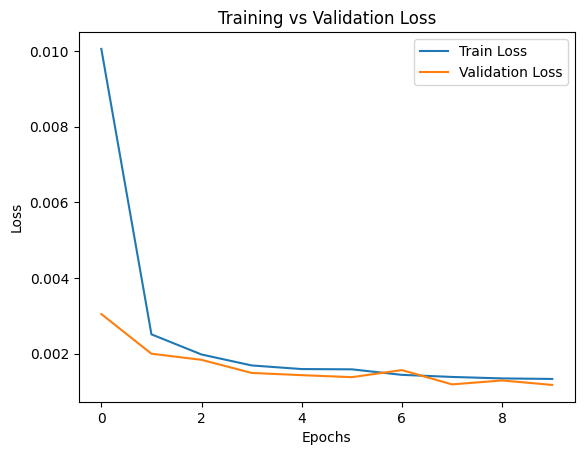

In [19]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

**Construct Anomaly Map**

In [20]:
def plot_reconstruction(input_img, reconstructed_img):
    error_map = np.abs(input_img - reconstructed_img)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(input_img, cmap="gray")
    ax[0].set_title("Input MRI")

    ax[1].imshow(reconstructed_img, cmap="gray")
    ax[1].set_title("Reconstructed MRI")

    ax[2].imshow(error_map, cmap="hot")
    ax[2].set_title("Reconstruction Error")

    plt.show()


Test Loss: 0.001189


TypeError: Invalid shape (128, 128, 128) for image data

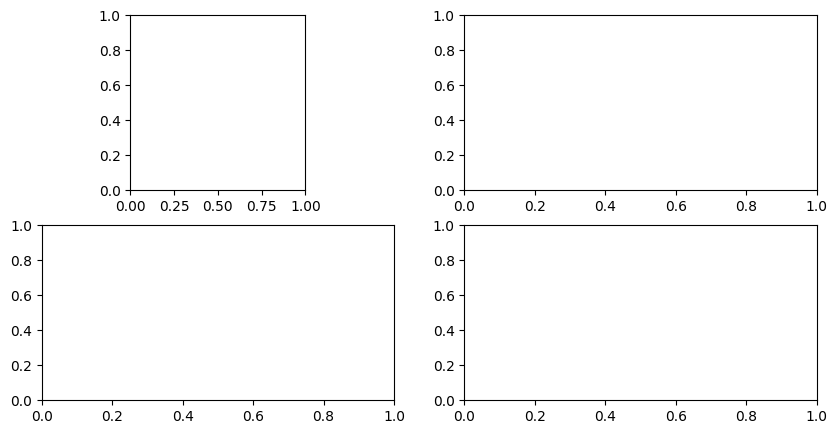

In [ ]:
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model.eval()

# Initialize loss tracking
test_losses = []
test_loss_total = 0.0

# Loop through testing dataset
for noisy_img, clean_img, modality in test_loader:
    noisy_img, clean_img, modality = noisy_img.to(device), clean_img.to(device), modality.to(device)
    
    with torch.no_grad():
        output = model(noisy_img, modality)
        loss = criterion(output, clean_img)
    
    test_losses.append(loss.item())
    test_loss_total += loss.item()

# Compute average validation loss
avg_val_loss = test_loss_total / len(test_loader)
print(f"Test Loss: {avg_val_loss:.6f}")

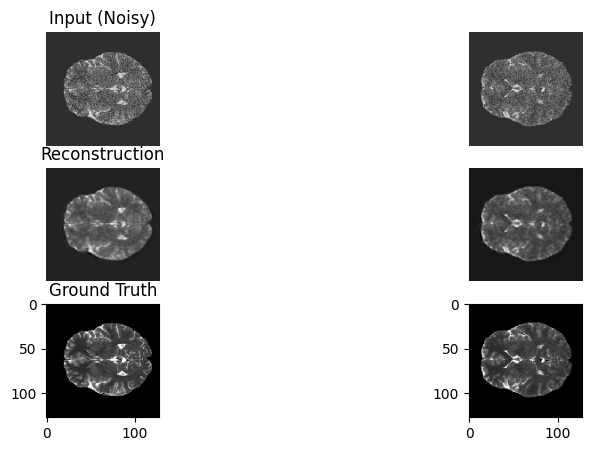

In [25]:
# Visualization of reconstructions (first batch only)
num_samples = min(4, noisy_img.shape[0])  # Show up to 4 images
inputs_np = noisy_img.cpu().numpy()
recon_np = output.cpu().numpy()
original_np = clean_img.cpu().numpy()

fig, axes = plt.subplots(3, num_samples, figsize=(10, 5))

for i in range(num_samples):
    mid_slice = inputs_np[i, 0, :, :, inputs_np.shape[-1] // 2]  # Middle slice along depth
    recon_slice = recon_np[i, 0, :, :, recon_np.shape[-1] // 2]  # Middle slice along depth
    orig_slice = original_np[i, 0, :, :, original_np.shape[-1] // 2]  # Middle slice along depth

    axes[0, i].imshow(mid_slice, cmap="gray")  # Noisy input
    axes[1, i].imshow(recon_slice, cmap="gray")  # Reconstructed output
    axes[2, i].imshow(orig_slice, cmap="gray")  # Ground truth
    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_title("Input (Noisy)")
axes[1, 0].set_title("Reconstruction")
axes[2, 0].set_title("Ground Truth")

plt.show()
